Algoritmos Metaheuristicos  
Tarea 4 - TSP con Restricciones  
Autor: Ing. Daniel Eduardo González Alvarado  
Profesor: Dr. Marco Aceves

# Importar Librerias

In [2]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import math
from collections import Counter

# Ciudades

In [25]:
cities = [
    ("Berlin",0,52.51884773857526, 13.399316235955151),
    ("Hamburg",1,53.548785437440195, 9.977200728960295),
    ("Stutgart",2,48.77623839616392, 9.17034612779568),
    ("Munich",3,48.13472194898543, 11.583031831234262),
    ("Paris",4,48.85747013862754, 2.3549279091667925),
    ("Lyon",5,45.76393127612354, 4.832719898555559),
    ("Bordeaux",6,44.84168369429339, -0.5832662702112001),
    ("Toulouse",7,43.605645872252836, 1.4410794437562802),
    ("Amsterdam",8,52.36721660836615, 4.89571821124265),
    ("Brussels",9,50.84880786029929, 4.360307832219759),
    ("Luxembourg",10,49.61236991982071, 6.123877571912193),
    ("Zurich",11,47.37787707746905, 8.53776278505955),
    ("Geneva",12,46.20409080254658, 6.140802969597529),
    ("Vienna",13,48.20867628708654, 16.371392213859014),
    ("Linz",14,48.306763621453875, 14.288670240608315),
    ("Roma",15,41.89819875411131, 12.484487843232444),
    ("Florencia",16,43.757311597683476, 11.496035565666629),
    ("Napoles",17,40.85260559077818, 14.26994532914783)
]

df = pd.DataFrame(cities, columns=["city","id" ,"lat", "lon"])
df_citys = df.copy()

In [4]:
def new_route():
    return random.sample(range(18), 18)

# Mapa

In [29]:
fig = go.Figure(go.Scattergeo(
    lon=df["lon"],
    lat=df["lat"],
    text=df["city"],
    mode="markers+text",
    textposition="bottom center",
    name="Ciudades"

))
# Recortado a nuestra zona de Interes
fig.update_geos(
    visible=False, resolution=110,
    showcountries=True, countrycolor="Black",
    lonaxis=dict(range=[-6, 23]),     # limita la longitud (Oeste hasta Este)
    lataxis=dict(range=[36, 60])      # limita la latitud (Sur a Norte)
)
# Tamaño Grafica
fig.update_layout(
    width=450, height=450,
    margin=dict(r=0, t=0, l=0, b=0)
)
# Captira de Mapa
fig.show(config={
    "staticPlot": True,       
    "displayModeBar": False
})
#fig.write_image("ciudades.png")

# Consideraciones

En este caso partimos de 18 ciudades en europa, sin embargo debemos tomar en cuenta ciertas restricciones, es decir que existiran ciudades a las cuales no podemos llegar, en un ejemplo real podria ser debido a rutas en reparacion o vuelos cancelados, etc.

# Matriz de Haversine

De cualquier manera necesitamos considerar todas las distancias entre las ciudades por lo cual calcularemos nuestra matriz y despues tomaremos en cuenta las restricciones.

In [30]:
def haversine_matrix(lat, lon):
    R = 6371008.8  # radio medio Tierra (m)
    phi = np.radians(lat)[:, None]     
    lam = np.radians(lon)[:, None]     
    dphi = phi.T - phi                 
    dlam = lam.T - lam
    a = np.sin(dphi/2)**2 + np.cos(phi) * np.cos(phi.T) * np.sin(dlam/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c  

In [31]:
lat = df["lat"].to_numpy(float)
lon = df["lon"].to_numpy(float)
D = haversine_matrix(lat, lon)

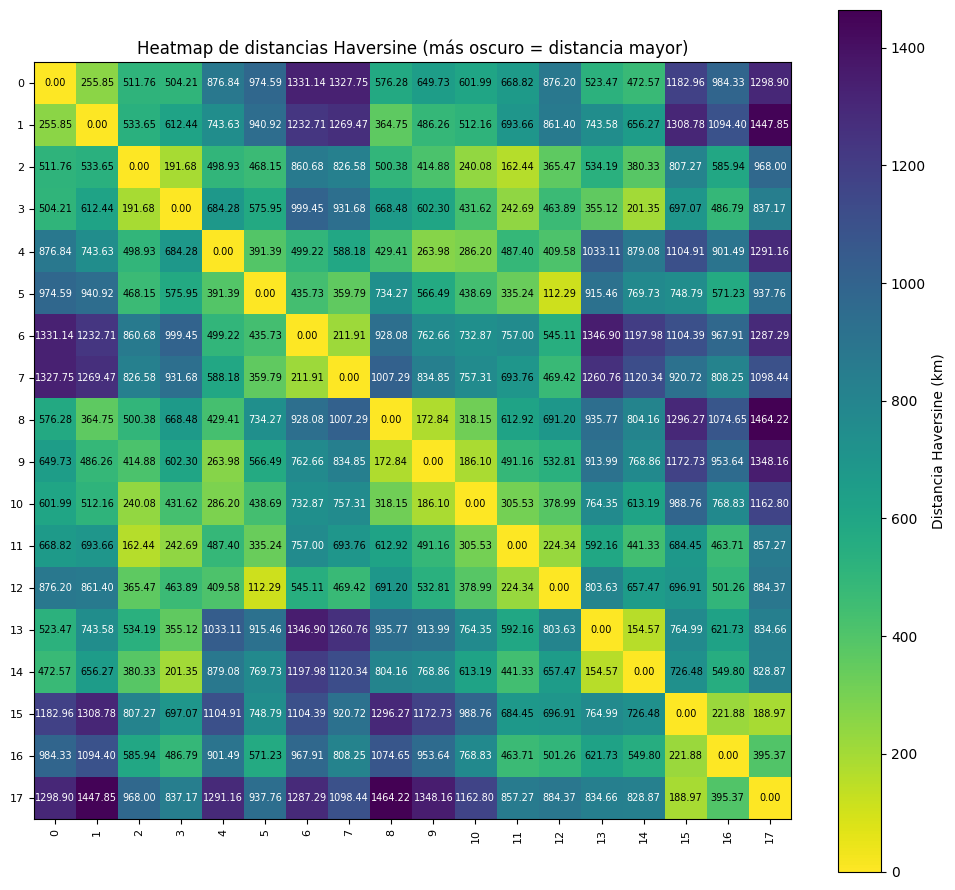

In [37]:
import numpy as np
import matplotlib.pyplot as plt

def plot_haversine_heatmap(D, labels=None):
    """
    D: matriz NxN de distancias (en metros)
    labels: lista/Serie de N etiquetas (opcional)
    """
    # Convertir a km
    M = (D / 1000).astype(float)

    # Crear figura
    fig, ax = plt.subplots(figsize=(10,9))
    
    # Mostrar matriz sin invertir ejes (diagonal de arriba-izq a abajo-der)
    im = ax.imshow(M, cmap='viridis_r', origin='upper')
    cbar = fig.colorbar(im, ax=ax, label='Distancia Haversine (km)')

    # Etiquetas
    if labels is None:
        labels = [str(i) for i in range(len(M))]
    ax.set_xticks(range(len(M))); ax.set_yticks(range(len(M)))
    ax.set_xticklabels(labels, rotation=90, fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_title('Heatmap de distancias Haversine (más oscuro = distancia mayor)')

    # Mostrar valores dentro de cada celda
    for i in range(len(M)):
        for j in range(len(M)):
            ax.text(j, i, f"{M[i, j]:.2f}", ha='center', va='center',
                    color='white' if M[i, j] > np.nanmax(M)/2 else 'black', fontsize=7)

    plt.tight_layout()
    plt.show()

# Ejemplo de uso
labels = df['nombre'].tolist() if 'nombre' in df.columns else None
plot_haversine_heatmap(D, labels=labels)
